## Benchmarking RSM, GP, ANN Modeling Approaches for Design of Experiments
Systematic benchmarking of three complementary modeling approaches — classical Response Surface Methodology (RSM), Gaussian Process (GP) surrogates, and H2O Deep Learning (ANN) — acrossDesign of Experiments datasets for BBD, CCD, DSD, Taguchi, CCFD.


In [1]:
# Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})
from scipy import stats
from itertools import combinations
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

model_order = ['RSM', 'GP', 'ANN', 'Ensemble']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

In [2]:
met_df = pd.read_excel('Metrics.xlsx')
met_df

,DESIGN_TYPE,SCALING_METHOD,RESPONSE,NUM_FACTORS,TRAIN_SIZE,TEST_SIZE,MODEL,MASE,MAPE,TOPOLOGY,EPOCHS,KERNEL_FUNCTION,ACTIVATION_FUNCTION
0,BBD,CODED,t,3,17,5,RSM,0.162265,3.411621,NaN,NaN,NaN,NaN
1,BBD,STANDARDIZED,t,3,17,5,GP,0.418507,8.799106,NaN,NaN,Matern3_2,NaN
2,BBD,STANDARDIZED,t,3,17,5,ANN,0.632008,13.287968,8,50.0,NaN,Tanh
3,BBD,RSM:CODED; GP/ANN:STANDARDIZED,t,3,17,5,Ensemble,0.297548,6.255943,8,50.0,Matern3_2,Tanh
4,BBD,CODED,KGM,3,17,5,RSM,0.002098,0.014629,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,FFD,GP/ANN:STANDARDIZED,Cell,7,16,8,Ensemble,1.339331,88.379287,8-5,28.0,Gaussian,Tanh
316,FD,NONE,yield,3,13,9,RSM,0.344779,5.091146,NaN,NaN,NaN,NaN
317,FD,STANDARDIZED,yield,3,13,9,GP,NaN,NaN,NaN,NaN,Gaussian,NaN
318,FD,STANDARDIZED,yield,3,13,9,ANN,0.571876,7.968865,8-5,59.0,NaN,Rectifier


In [7]:
# ── 1. Summary statistics by MODEL ──────────────────────────────────
summary = met_df.groupby('MODEL')[['MASE','MAPE']].agg(['mean','median','std','min','max','count']).sort_values(by=('MASE', 'mean'), ascending=True)
print("=== Summary Statistics by MODEL ===")
print(summary.to_string())

=== Summary Statistics by MODEL ===
                  MASE                                                                     MAPE                                                          
                  mean    median            std           min           max count          mean    median           std           min           max count
MODEL                                                                                                                                                    
Ensemble      0.655572  0.304276       1.561161  1.647268e-15  1.307053e+01    72  1.913065e+01  5.671630  5.435378e+01  2.849768e-14  4.274464e+02    80
GP            0.798504  0.425002       1.636916  1.923500e-03  1.312440e+01    79  1.988930e+01  7.306550  3.774339e+01  7.641898e-02  2.225608e+02    79
ANN           5.906934  0.560036      23.946772  6.826576e-02  1.417210e+02    72  1.423841e+02  9.376619  7.846306e+02  9.346335e-03  6.880252e+03    80
RSM       35247.295511  0.405036  285764

In [8]:
# ── 2. Pairwise Wilcoxon rank-sum tests ─────────────────────────────
models = model_order
print("\n=== Pairwise Wilcoxon Rank-Sum Tests ===")
pw_results = {}
for metric in ['MASE', 'MAPE']:
    print(f"\n--- {metric} ---")
    pw_results[metric] = {}
    for m1, m2 in combinations(models, 2):
        g1 = met_df.loc[met_df['MODEL'] == m1, metric].dropna()
        g2 = met_df.loc[met_df['MODEL'] == m2, metric].dropna()
        stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p={pval:.4e}  {sig}")
        pw_results[metric][(m1, m2)] = pval


=== Pairwise Wilcoxon Rank-Sum Tests ===

--- MASE ---
         RSM vs GP          U=    2931.0  p=7.4726e-01  ns
         RSM vs ANN         U=    2312.0  p=2.6410e-01  ns
         RSM vs Ensemble    U=    3060.0  p=6.1775e-02  ns
          GP vs ANN         U=    2340.0  p=6.0682e-02  ns
          GP vs Ensemble    U=    3292.0  p=9.5479e-02  ns
         ANN vs Ensemble    U=    3436.0  p=7.5106e-04  ***

--- MAPE ---
         RSM vs GP          U=    3249.0  p=7.6046e-01  ns
         RSM vs ANN         U=    2876.0  p=2.6960e-01  ns
         RSM vs Ensemble    U=    3650.0  p=1.2504e-01  ns
          GP vs ANN         U=    2649.0  p=7.8645e-02  ns
          GP vs Ensemble    U=    3590.0  p=1.3899e-01  ns
         ANN vs Ensemble    U=    4096.0  p=2.2431e-03  **


In [9]:
# ── ANOVA & Kruskal-Wallis: RSM vs GP vs ANN vs Ensemble ────────────
from scipy.stats import f_oneway, kruskal, levene, shapiro

for metric in ['MASE', 'MAPE']:
    groups = [met_df.loc[met_df['MODEL'] == m, metric].dropna().values for m in model_order]

    print(f"\n{'='*60}")
    print(f"  {metric}")
    print(f"{'='*60}")

    # ── Assumption checks ───────────────────────────────────────
    # Shapiro-Wilk normality test per group
    print("\nShapiro-Wilk normality test:")
    for m, g in zip(model_order, groups):
        if len(g) >= 3:
            w, p = shapiro(g)
            print(f"  {m:>10s}:  W={w:.4f}  p={p:.4e}  {'normal' if p > 0.05 else 'non-normal'}")

    # Levene's test for homogeneity of variances
    lev_stat, lev_p = levene(*groups)
    print(f"\nLevene's test (equal variances):  stat={lev_stat:.4f}  p={lev_p:.4e}  "
          f"{'equal' if lev_p > 0.05 else 'unequal'}")

    # ── One-way ANOVA ───────────────────────────────────────────
    f_stat, anova_p = f_oneway(*groups)
    print(f"\nOne-way ANOVA:  F={f_stat:.4f}  p={anova_p:.4e}  "
          f"{'***' if anova_p < 0.001 else '**' if anova_p < 0.01 else '*' if anova_p < 0.05 else 'ns'}")

    # ── Kruskal-Wallis (non-parametric alternative) ─────────────
    h_stat, kw_p = kruskal(*groups)
    print(f"Kruskal-Wallis: H={h_stat:.4f}  p={kw_p:.4e}  "
          f"{'***' if kw_p < 0.001 else '**' if kw_p < 0.01 else '*' if kw_p < 0.05 else 'ns'}")

    # ── Post-hoc Dunn's test (if Kruskal-Wallis significant) ────
    if kw_p < 0.05:
        try:
            import scikit_posthocs as sp
            dunn = sp.posthoc_dunn(met_df, val_col=metric, group_col='MODEL', p_adjust='bonferroni')
            print(f"\nDunn's post-hoc test (Bonferroni-adjusted p-values):")
            print(dunn.to_string())
        except ImportError:
            print("\n  (Install scikit-posthocs for Dunn's post-hoc test: pip install scikit-posthocs)")
            # Fallback: pairwise Mann-Whitney with Bonferroni correction
            from itertools import combinations
            n_comp = len(list(combinations(model_order, 2)))
            print(f"\n  Pairwise Mann-Whitney U with Bonferroni correction ({n_comp} comparisons):")
            for m1, m2 in combinations(model_order, 2):
                g1 = met_df.loc[met_df['MODEL'] == m1, metric].dropna()
                g2 = met_df.loc[met_df['MODEL'] == m2, metric].dropna()
                stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                adj_p = min(pval * n_comp, 1.0)
                sig = '***' if adj_p < 0.001 else '**' if adj_p < 0.01 else '*' if adj_p < 0.05 else 'ns'
                print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p_adj={adj_p:.4e}  {sig}")


  MASE

Shapiro-Wilk normality test:
         RSM:  W=0.1028  p=7.6779e-19  non-normal
          GP:  W=0.3640  p=8.1984e-17  non-normal
         ANN:  W=0.2427  p=1.9168e-17  non-normal
    Ensemble:  W=0.3081  p=1.0065e-16  non-normal

Levene's test (equal variances):  stat=1.1311  p=3.3673e-01  equal

One-way ANOVA:  F=1.1311  p=3.3673e-01  ns
Kruskal-Wallis: H=11.1510  p=1.0937e-02  *

Dunn's post-hoc test (Bonferroni-adjusted p-values):
               ANN  Ensemble        GP       RSM
ANN       1.000000  0.013658  0.631360  1.000000
Ensemble  0.013658  1.000000  0.799376  0.400876
GP        0.631360  0.799376  1.000000  1.000000
RSM       1.000000  0.400876  1.000000  1.000000

  MAPE

Shapiro-Wilk normality test:
         RSM:  W=0.1534  p=2.7675e-19  non-normal
          GP:  W=0.5057  p=7.1450e-15  non-normal
         ANN:  W=0.1622  p=3.4020e-19  non-normal
    Ensemble:  W=0.3272  p=2.2797e-17  non-normal

Levene's test (equal variances):  stat=2.1730  p=9.1150e-02  equal

O

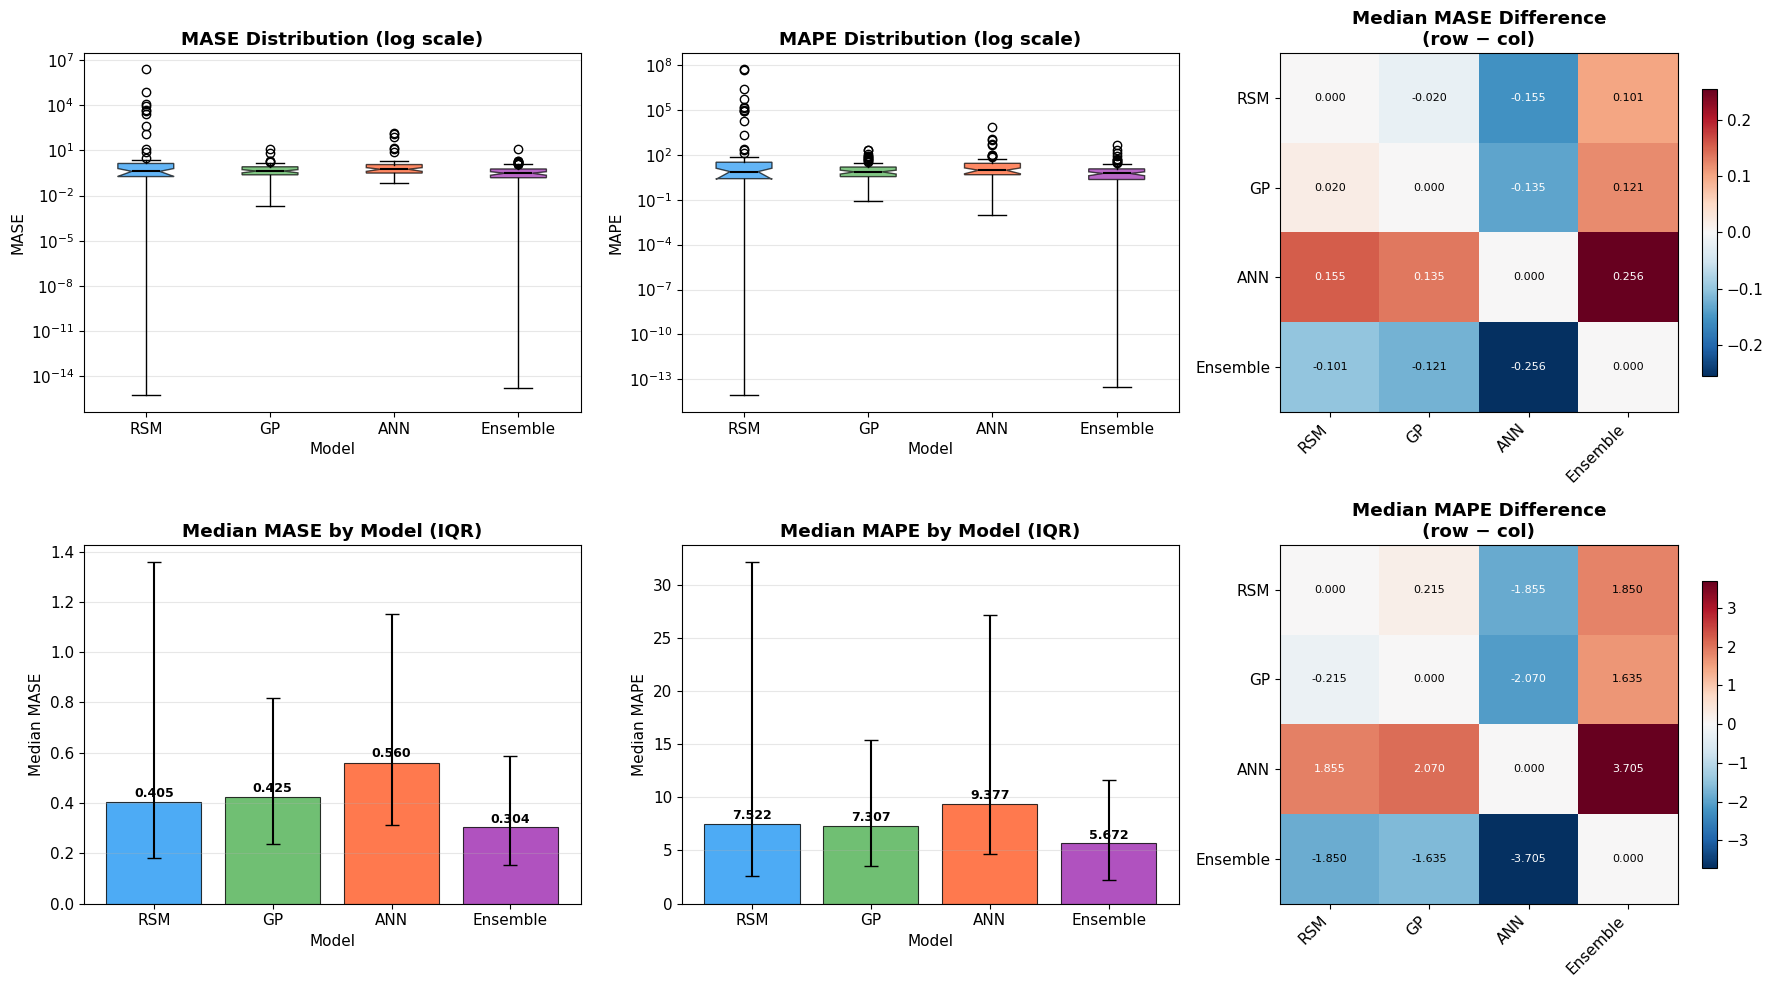

In [10]:
# ── 3. Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, metric in enumerate(['MASE', 'MAPE']):
    data_groups = [met_df.loc[met_df['MODEL'] == m, metric].dropna().values for m in model_order]

    # (a) Box plot – log scale to handle outliers
    ax = axes[0, col_idx]
    bp = ax.boxplot(data_groups, tick_labels=model_order, patch_artist=True, notch=True,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_yscale('log')
    ax.set_title(f'{metric} Distribution (log scale)', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)

    # (b) Median bar chart (robust to outliers)
    ax = axes[1, col_idx]
    medians = [np.median(g) for g in data_groups]
    q25 = [np.percentile(g, 25) for g in data_groups]
    q75 = [np.percentile(g, 75) for g in data_groups]
    yerr_low = [med - q for med, q in zip(medians, q25)]
    yerr_high = [q - med for med, q in zip(medians, q75)]
    bars = ax.bar(model_order, medians, yerr=[yerr_low, yerr_high], capsize=5,
                  color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
    ax.set_title(f'Median {metric} by Model (IQR)', fontweight='bold')
    ax.set_ylabel(f'Median {metric}')
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)
    for bar, m in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# (c) Pairwise mean-difference heatmaps
for row_idx, metric in enumerate(['MASE', 'MAPE']):
    ax = axes[row_idx, 2]
    n = len(model_order)
    diff_mat = np.zeros((n, n))
    for i, m1 in enumerate(model_order):
        for j, m2 in enumerate(model_order):
            diff_mat[i, j] = (met_df.loc[met_df['MODEL'] == m1, metric].median()
                              - met_df.loc[met_df['MODEL'] == m2, metric].median())
    im = ax.imshow(diff_mat, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(n)); ax.set_xticklabels(model_order, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(model_order)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{diff_mat[i,j]:.3f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(diff_mat[i,j]) > np.max(np.abs(diff_mat))*0.5 else 'black')
    ax.set_title(f'Median {metric} Difference\n(row − col)', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
# plt.savefig('model_MASE_MAPE_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# print("\nPlot saved as 'model_MASE_MAPE_comparison.png'")

Rows: 320 original → 251 after removing 69 outlier rows

Per-model counts (original → cleaned):
         RSM: 80 → 57  (removed 23)
          GP: 80 → 66  (removed 14)
         ANN: 80 → 67  (removed 13)
    Ensemble: 80 → 61  (removed 19)


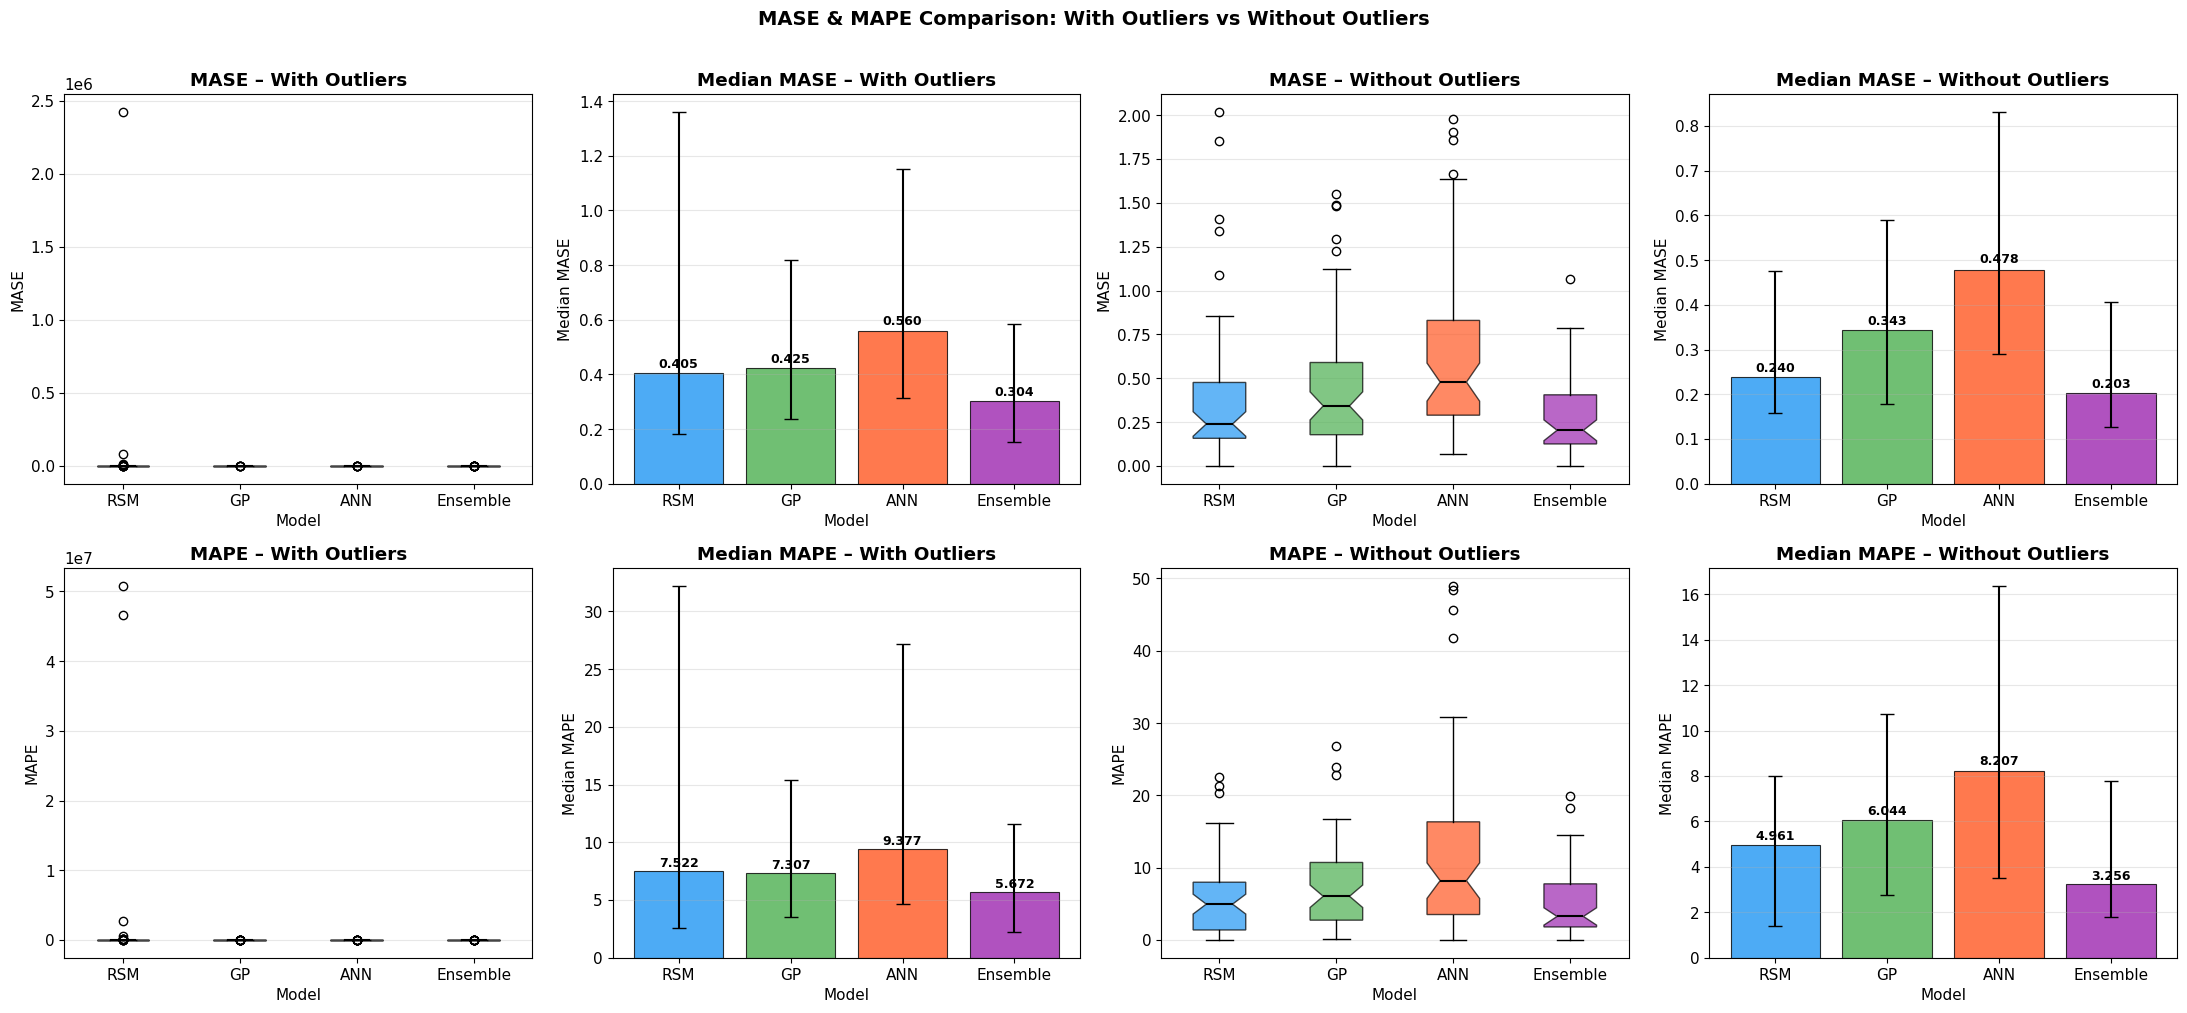


COMPARISON TABLE: Median (Mean ± Std) with and without outliers
Model      Metric                  With Outliers                Without Outliers    Δ Median
------------------------------------------------------------------------------------------
RSM        MASE   med=   0.405 (μ= 35247.296 ± 285764.452)  med=   0.240 (μ=     0.400 ±      0.445)      -0.165
GP         MASE   med=   0.425 (μ=     0.799 ±      1.637)  med=   0.343 (μ=     0.451 ±      0.383)      -0.082
ANN        MASE   med=   0.560 (μ=     5.907 ±     23.947)  med=   0.478 (μ=     0.630 ±      0.495)      -0.082
Ensemble   MASE   med=   0.304 (μ=     0.656 ±      1.561)  med=   0.203 (μ=     0.272 ±      0.215)      -0.101

RSM        MAPE   med=   7.522 (μ=1264651.726 ± 7656908.221)  med=   4.961 (μ=     5.670 ±      5.367)      -2.561
GP         MAPE   med=   7.307 (μ=    19.889 ±     37.743)  med=   6.044 (μ=     7.388 ±      6.111)      -1.262
ANN        MAPE   med=   9.377 (μ=   142.384 ±    784.631)  med=   8.2

In [12]:
# ── 4. With vs Without Outliers Comparison ──────────────────────────────
# Remove outliers using IQR method per MODEL per metric
def remove_outliers_iqr(df, group_col, metric_col):
    """Remove rows where metric is outside 1.5*IQR per group."""
    mask = pd.Series(True, index=df.index)
    for grp in df[group_col].unique():
        idx = df[group_col] == grp
        q1 = df.loc[idx, metric_col].quantile(0.25)
        q3 = df.loc[idx, metric_col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask &= ~(idx & ((df[metric_col] < lower) | (df[metric_col] > upper)))
    return df[mask]

# Build cleaned df (outliers removed for both MASE and MAPE simultaneously)
clean_df = met_df.copy()
for m in ['MASE', 'MAPE']:
    clean_df = remove_outliers_iqr(clean_df, 'MODEL', m)

n_removed = len(met_df) - len(clean_df)
print(f"Rows: {len(met_df)} original → {len(clean_df)} after removing {n_removed} outlier rows")
print(f"\nPer-model counts (original → cleaned):")
for m in model_order:
    n_orig = (met_df['MODEL'] == m).sum()
    n_clean = (clean_df['MODEL'] == m).sum()
    print(f"  {m:>10s}: {n_orig} → {n_clean}  (removed {n_orig - n_clean})")

# ── Side-by-side comparison plots ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('MASE & MAPE Comparison: With Outliers vs Without Outliers', fontsize=14, fontweight='bold', y=1.01)

datasets = [('With Outliers', met_df), ('Without Outliers', clean_df)]

for row_idx, metric in enumerate(['MASE', 'MAPE']):
    for ds_idx, (label, data) in enumerate(datasets):
        # Box plots
        ax = axes[row_idx, ds_idx * 2]
        data_groups = [data.loc[data['MODEL'] == m, metric].dropna().values for m in model_order]
        bp = ax.boxplot(data_groups, tick_labels=model_order, patch_artist=True, notch=True,
                        medianprops=dict(color='black', linewidth=1.5))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(f'{metric} – {label}', fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_xlabel('Model')
        ax.grid(axis='y', alpha=0.3)

        # Bar charts (median + IQR)
        ax2 = axes[row_idx, ds_idx * 2 + 1]
        medians = [np.median(g) for g in data_groups]
        q25 = [np.percentile(g, 25) for g in data_groups]
        q75 = [np.percentile(g, 75) for g in data_groups]
        yerr_low = [med - q for med, q in zip(medians, q25)]
        yerr_high = [q - med for med, q in zip(medians, q75)]
        bars = ax2.bar(model_order, medians, yerr=[yerr_low, yerr_high], capsize=5,
                       color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
        ax2.set_title(f'Median {metric} – {label}', fontweight='bold')
        ax2.set_ylabel(f'Median {metric}')
        ax2.set_xlabel('Model')
        ax2.grid(axis='y', alpha=0.3)
        for bar, mv in zip(bars, medians):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                     f'{mv:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Summary table: with vs without outliers ─────────────────────────
print("\n" + "="*80)
print("COMPARISON TABLE: Median (Mean ± Std) with and without outliers")
print("="*80)
print(f"{'Model':<10} {'Metric':<6} {'With Outliers':>30}  {'Without Outliers':>30}  {'Δ Median':>10}")
print("-"*90)
for metric in ['MASE', 'MAPE']:
    for m in model_order:
        orig = met_df.loc[met_df['MODEL'] == m, metric]
        cln = clean_df.loc[clean_df['MODEL'] == m, metric]
        delta = cln.median() - orig.median()
        print(f"{m:<10} {metric:<6} "
              f"med={orig.median():8.3f} (μ={orig.mean():10.3f} ± {orig.std():10.3f})  "
              f"med={cln.median():8.3f} (μ={cln.mean():10.3f} ± {cln.std():10.3f})  "
              f"{delta:+10.3f}")
    print()

# ── Pairwise Wilcoxon tests WITHOUT outliers ────────────────────────
print("=== Pairwise Wilcoxon Rank-Sum Tests (WITHOUT outliers) ===")
for metric in ['MASE', 'MAPE']:
    print(f"\n--- {metric} ---")
    for m1, m2 in combinations(models, 2):
        g1 = clean_df.loc[clean_df['MODEL'] == m1, metric].dropna()
        g2 = clean_df.loc[clean_df['MODEL'] == m2, metric].dropna()
        stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p={pval:.4e}  {sig}")

In [13]:
# ── 6. ANOVA & Kruskal-Wallis (WITHOUT outliers) ────────────────────────
from scipy.stats import f_oneway, kruskal, levene, shapiro

for metric in ['MASE', 'MAPE']:
    groups = [clean_df.loc[clean_df['MODEL'] == m, metric].dropna().values for m in model_order]

    print(f"\n{'='*60}")
    print(f"  {metric}  (outliers removed)")
    print(f"{'='*60}")

    # ── Assumption checks ───────────────────────────────────────
    print("\nShapiro-Wilk normality test:")
    for m, g in zip(model_order, groups):
        if len(g) >= 3:
            w, p = shapiro(g)
            print(f"  {m:>10s}:  W={w:.4f}  p={p:.4e}  {'normal' if p > 0.05 else 'non-normal'}")

    lev_stat, lev_p = levene(*groups)
    print(f"\nLevene's test (equal variances):  stat={lev_stat:.4f}  p={lev_p:.4e}  "
          f"{'equal' if lev_p > 0.05 else 'unequal'}")

    # ── One-way ANOVA ───────────────────────────────────────────
    f_stat, anova_p = f_oneway(*groups)
    print(f"\nOne-way ANOVA:  F={f_stat:.4f}  p={anova_p:.4e}  "
          f"{'***' if anova_p < 0.001 else '**' if anova_p < 0.01 else '*' if anova_p < 0.05 else 'ns'}")

    # ── Kruskal-Wallis (non-parametric alternative) ─────────────
    h_stat, kw_p = kruskal(*groups)
    print(f"Kruskal-Wallis: H={h_stat:.4f}  p={kw_p:.4e}  "
          f"{'***' if kw_p < 0.001 else '**' if kw_p < 0.01 else '*' if kw_p < 0.05 else 'ns'}")

    # ── Post-hoc Dunn's test (if Kruskal-Wallis significant) ────
    if kw_p < 0.05:
        try:
            import scikit_posthocs as sp
            dunn = sp.posthoc_dunn(clean_df, val_col=metric, group_col='MODEL', p_adjust='bonferroni')
            print(f"\nDunn's post-hoc test (Bonferroni-adjusted p-values):")
            print(dunn.to_string())
        except ImportError:
            print("\n  (Install scikit-posthocs for Dunn's post-hoc test: pip install scikit-posthocs)")
            from itertools import combinations
            n_comp = len(list(combinations(model_order, 2)))
            print(f"\n  Pairwise Mann-Whitney U with Bonferroni correction ({n_comp} comparisons):")
            for m1, m2 in combinations(model_order, 2):
                g1 = clean_df.loc[clean_df['MODEL'] == m1, metric].dropna()
                g2 = clean_df.loc[clean_df['MODEL'] == m2, metric].dropna()
                stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                adj_p = min(pval * n_comp, 1.0)
                sig = '***' if adj_p < 0.001 else '**' if adj_p < 0.01 else '*' if adj_p < 0.05 else 'ns'
                print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p_adj={adj_p:.4e}  {sig}")


  MASE  (outliers removed)

Shapiro-Wilk normality test:
         RSM:  W=0.7342  p=2.8743e-08  non-normal
          GP:  W=0.8743  p=8.4938e-06  non-normal
         ANN:  W=0.8685  p=9.6825e-06  non-normal
    Ensemble:  W=0.8912  p=1.2438e-04  non-normal

Levene's test (equal variances):  stat=3.9380  p=9.1232e-03  unequal

One-way ANOVA:  F=8.0103  p=4.2440e-05  ***
Kruskal-Wallis: H=23.8920  p=2.6311e-05  ***

Dunn's post-hoc test (Bonferroni-adjusted p-values):
               ANN  Ensemble        GP       RSM
ANN       1.000000  0.000108  0.298060  0.010894
Ensemble  0.000108  1.000000  0.087426  1.000000
GP        0.298060  0.087426  1.000000  1.000000
RSM       0.010894  1.000000  1.000000  1.000000

  MAPE  (outliers removed)

Shapiro-Wilk normality test:
         RSM:  W=0.8439  p=3.2912e-06  non-normal
          GP:  W=0.9063  p=1.2418e-04  non-normal
         ANN:  W=0.8305  p=2.7341e-07  non-normal
    Ensemble:  W=0.8757  p=1.6573e-05  non-normal

Levene's test (equal var

In [14]:
# ── 7. Model comparison by DESIGN_TYPE (outliers removed) ───────────────
from scipy.stats import f_oneway, kruskal, levene, shapiro
from itertools import combinations

design_types = sorted(clean_df['DESIGN_TYPE'].dropna().unique())
print(f"Design types found: {design_types}\n")

for dt in design_types:
    sub = clean_df[clean_df['DESIGN_TYPE'] == dt]
    print(f"\n{'#'*70}")
    print(f"  DESIGN TYPE: {dt}   (n = {len(sub)})")
    print(f"{'#'*70}")

    for metric in ['MASE', 'MAPE']:
        groups = [sub.loc[sub['MODEL'] == m, metric].dropna().values for m in model_order]
        sizes = [len(g) for g in groups]

        print(f"\n{'='*60}")
        print(f"  {metric}  |  {dt}")
        print(f"{'='*60}")
        print(f"  Group sizes: {dict(zip(model_order, sizes))}")

        # Skip if any group has fewer than 3 observations
        if any(s < 3 for s in sizes):
            print("  ⚠ Skipping — at least one model has < 3 observations for this design type.")
            continue

        # ── Descriptive stats ───────────────────────────────────
        print(f"\n  {'Model':<10} {'n':>4} {'Median':>10} {'Mean':>10} {'Std':>10}")
        print(f"  {'-'*48}")
        for m, g in zip(model_order, groups):
            print(f"  {m:<10} {len(g):>4} {np.median(g):>10.4f} {np.mean(g):>10.4f} {np.std(g, ddof=1):>10.4f}")

        # ── Shapiro-Wilk normality ──────────────────────────────
        print("\n  Shapiro-Wilk normality:")
        for m, g in zip(model_order, groups):
            w, p = shapiro(g)
            print(f"    {m:>10s}:  W={w:.4f}  p={p:.4e}  {'normal' if p > 0.05 else 'non-normal'}")

        # ── Levene's test ───────────────────────────────────────
        lev_stat, lev_p = levene(*groups)
        print(f"\n  Levene's test:  stat={lev_stat:.4f}  p={lev_p:.4e}  "
              f"{'equal' if lev_p > 0.05 else 'unequal'}")

        # ── One-way ANOVA ───────────────────────────────────────
        f_stat, anova_p = f_oneway(*groups)
        sig = '***' if anova_p < 0.001 else '**' if anova_p < 0.01 else '*' if anova_p < 0.05 else 'ns'
        print(f"\n  One-way ANOVA:  F={f_stat:.4f}  p={anova_p:.4e}  {sig}")

        # ── Kruskal-Wallis ──────────────────────────────────────
        h_stat, kw_p = kruskal(*groups)
        sig_kw = '***' if kw_p < 0.001 else '**' if kw_p < 0.01 else '*' if kw_p < 0.05 else 'ns'
        print(f"  Kruskal-Wallis: H={h_stat:.4f}  p={kw_p:.4e}  {sig_kw}")

        # ── Pairwise Wilcoxon Rank-Sum Tests ────────────────────
        print(f"\n  Pairwise Wilcoxon Rank-Sum Tests:")
        for m1, m2 in combinations(model_order, 2):
            g1 = sub.loc[sub['MODEL'] == m1, metric].dropna()
            g2 = sub.loc[sub['MODEL'] == m2, metric].dropna()
            stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            sig_w = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p={pval:.4e}  {sig_w}")

        # ── Mann-Whitney U with Bonferroni correction ───────────
        n_comp = len(list(combinations(model_order, 2)))
        print(f"\n  Mann-Whitney U with Bonferroni correction ({n_comp} comparisons):")
        for m1, m2 in combinations(model_order, 2):
            g1 = sub.loc[sub['MODEL'] == m1, metric].dropna()
            g2 = sub.loc[sub['MODEL'] == m2, metric].dropna()
            stat, pval = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            adj_p = min(pval * n_comp, 1.0)
            s = '***' if adj_p < 0.001 else '**' if adj_p < 0.01 else '*' if adj_p < 0.05 else 'ns'
            print(f"    {m1:>10s} vs {m2:<10s}  U={stat:10.1f}  p_adj={adj_p:.4e}  {s}")

        # ── Dunn's post-hoc (if Kruskal-Wallis significant) ─────
        if kw_p < 0.05:
            try:
                import scikit_posthocs as sp
                dunn = sp.posthoc_dunn(sub, val_col=metric, group_col='MODEL', p_adjust='bonferroni')
                print(f"\n  Dunn's post-hoc (Bonferroni):")
                for line in dunn.to_string().split('\n'):
                    print(f"    {line}")
            except ImportError:
                pass

Design types found: ['BBD', 'CCD', 'CCFD', 'CCRD', 'DSD', 'FD', 'TAG']


######################################################################
  DESIGN TYPE: BBD   (n = 66)
######################################################################

  MASE  |  BBD
  Group sizes: {'RSM': 16, 'GP': 18, 'ANN': 17, 'Ensemble': 15}

  Model         n     Median       Mean        Std
  ------------------------------------------------
  RSM          16     0.1927     0.2680     0.2208
  GP           18     0.3338     0.4753     0.3742
  ANN          17     0.4818     0.5893     0.3797
  Ensemble     15     0.1563     0.2277     0.1973

  Shapiro-Wilk normality:
           RSM:  W=0.8713  p=2.8509e-02  non-normal
            GP:  W=0.8011  p=1.5725e-03  non-normal
           ANN:  W=0.8991  p=6.5572e-02  normal
      Ensemble:  W=0.8597  p=2.3873e-02  non-normal

  Levene's test:  stat=1.3434  p=2.6850e-01  equal

  One-way ANOVA:  F=4.9742  p=3.7117e-03  **
  Kruskal-Wallis: H=14.3820  p=2.4288e-